## chapter 2

pip install opencv-python

pip install matplotlib

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

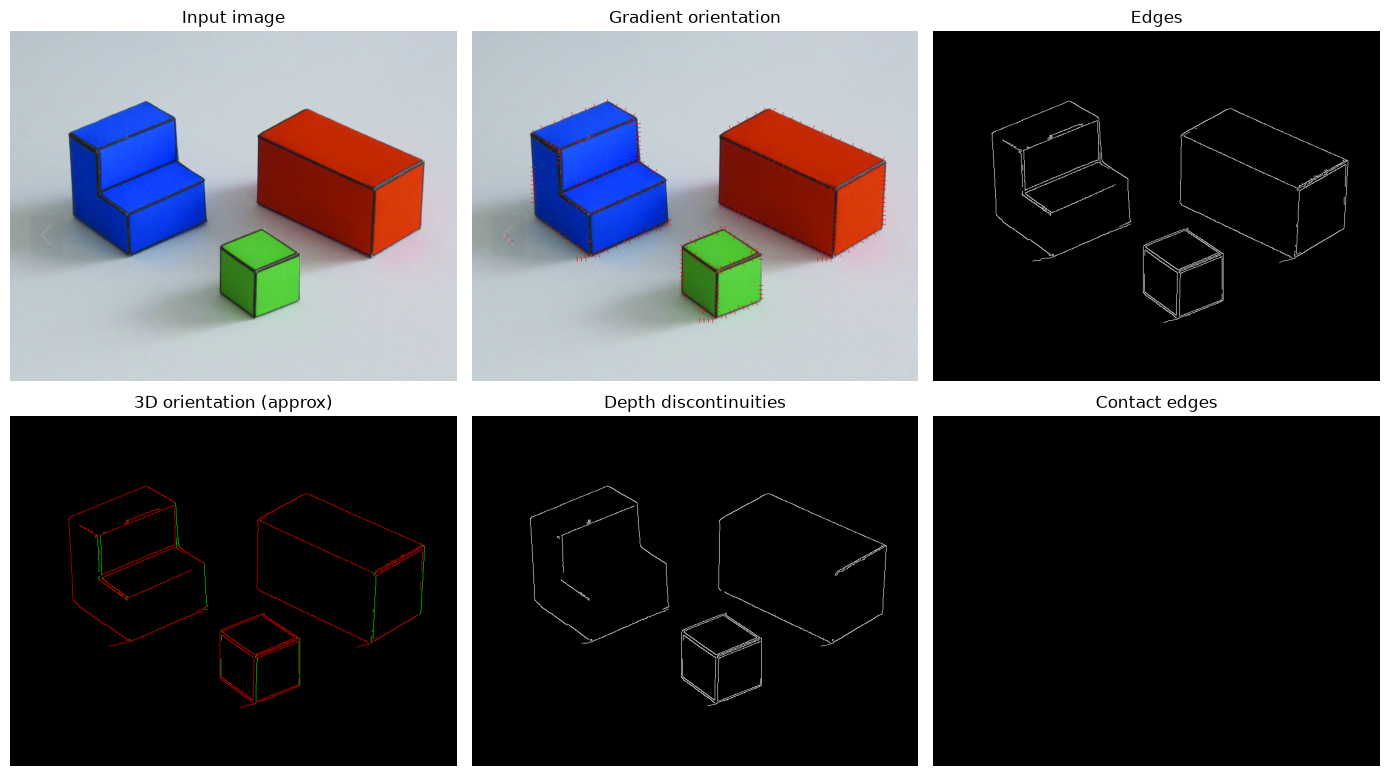

In [2]:
# -------------------------------------------------------
# Load image
# -------------------------------------------------------
img = cv2.imread("imgs/input.png")

rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# -------------------------------------------------------
# 1. Gradient magnitude and orientation
# -------------------------------------------------------
gx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
gy = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)

magnitude = np.sqrt(gx**2 + gy**2)
orientation = np.arctan2(gy, gx)

# Normalize for visualization
mag_vis = cv2.normalize(
    magnitude,
    None,
    0,
    255,
    cv2.NORM_MINMAX
).astype(np.uint8)

# -------------------------------------------------------
# 2. Edge extraction
# -------------------------------------------------------
edges = cv2.Canny(gray, 50, 150)

# -------------------------------------------------------
# 3. Gradient orientation visualization
# -------------------------------------------------------
orientation_img = rgb.copy()

step = 8

for y in range(0, gray.shape[0], step):
    for x in range(0, gray.shape[1], step):

        if magnitude[y, x] < 50:
            continue

        angle = orientation[y, x]

        dx = int(5 * np.cos(angle))
        dy = int(5 * np.sin(angle))

        cv2.line(
            orientation_img,
            (x - dx, y - dy),
            (x + dx, y + dy),
            (255, 0, 0),
            1
        )

# -------------------------------------------------------
# 4. Approximate depth discontinuities
#    Strong edges only
# -------------------------------------------------------
depth_edges = cv2.Canny(gray, 100, 250)

# -------------------------------------------------------
# 5. Approximate contact edges
#    Horizontal edges near image bottom
# -------------------------------------------------------
lines = cv2.HoughLinesP(
    edges,
    1,
    np.pi / 180,
    threshold=30,
    minLineLength=20,
    maxLineGap=5
)

contact = np.zeros_like(edges)

if lines is not None:

    for l in lines:

        x1, y1, x2, y2 = l[0]

        angle = np.degrees(
            np.arctan2(y2 - y1, x2 - x1)
        )

        if abs(angle) < 20:
            if max(y1, y2) > gray.shape[0] * 0.6:

                cv2.line(
                    contact,
                    (x1, y1),
                    (x2, y2),
                    255,
                    1
                )

# -------------------------------------------------------
# 6. Approximate 3D orientation
# -------------------------------------------------------
orientation3d = np.zeros((*gray.shape, 3), dtype=np.uint8)

vertical = np.abs(np.degrees(orientation)) > 45
horizontal = ~vertical

orientation3d[..., 1] = horizontal * (edges > 0) * 255
orientation3d[..., 0] = vertical * (edges > 0) * 255

# -------------------------------------------------------
# Display
# -------------------------------------------------------
fig, ax = plt.subplots(2, 3, figsize=(14, 8))

ax[0,0].imshow(rgb)
ax[0,0].set_title("Input image")

ax[0,1].imshow(orientation_img)
ax[0,1].set_title("Gradient orientation")

ax[0,2].imshow(edges, cmap='gray')
ax[0,2].set_title("Edges")

ax[1,0].imshow(orientation3d)
ax[1,0].set_title("3D orientation (approx)")

ax[1,1].imshow(depth_edges, cmap='gray')
ax[1,1].set_title("Depth discontinuities")

ax[1,2].imshow(contact, cmap='gray')
ax[1,2].set_title("Contact edges")

for a in ax.ravel():
    a.axis("off")

plt.tight_layout()
plt.show()